# Анализ и визуализация данных



Разберем способы построения основных графиков.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
plt.style.use('seaborn-v0_8-ticks') # plt.style.available
plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams.update({'font.size': 14})

### Загрузка данных в объект DataFrame

ссылка на файл - https://drive.google.com/file/d/1hiJUAB5NA6B-Jqk3Bv3zjg_3rJ17qydJ/view?usp=sharing

In [31]:
!gdown 1hiJUAB5NA6B-Jqk3Bv3zjg_3rJ17qydJ
df = pd.read_csv('/content/IMDB-Movie-Data.csv')

Downloading...
From: https://drive.google.com/uc?id=1hiJUAB5NA6B-Jqk3Bv3zjg_3rJ17qydJ
To: /content/IMDB-Movie-Data.csv
100% 310k/310k [00:00<00:00, 111MB/s]


https://www.kaggle.com/PromptCloudHQ/imdb-data
Here's a data set of 1,000 most popular movies on IMDB from 2006 to 2016. The data points included are:
Title, Genre, Description, Director, Actors, Year, Runtime, Rating, Votes, Revenue, Metascrore.

### Гистограмма и график плотности распределения (hist & kdeplot)

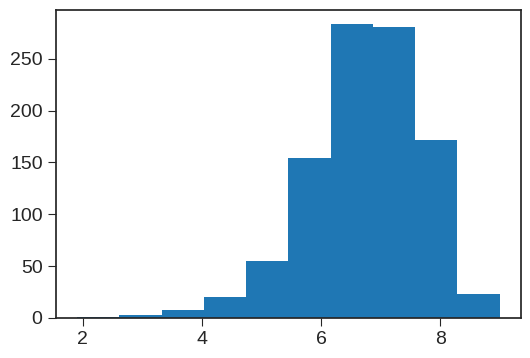

In [8]:
plt.hist(df['Rating']); # строим гистограмму

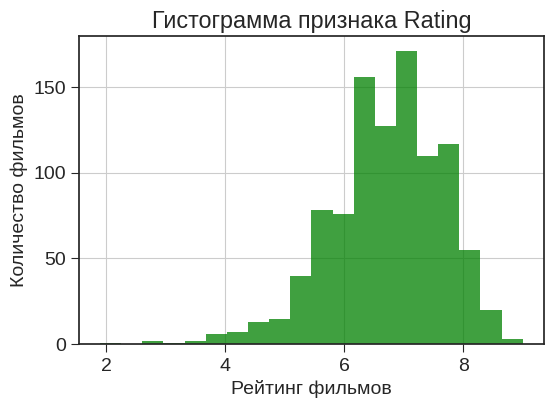

In [9]:
plt.hist(df['Rating'], bins=20, color='green', alpha=0.75)

plt.xlabel('Рейтинг фильмов')
plt.ylabel('Количество фильмов')
plt.title('Гистограмма признака Rating')
plt.grid(True);

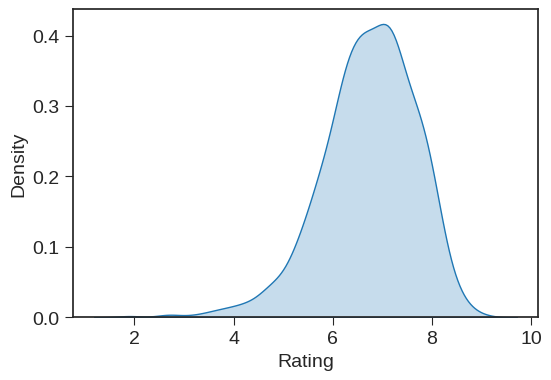

In [33]:
# строим график плотности распределения (ядерная оценка плотности)
sns.kdeplot(df['Rating'], fill='fill', legend=False);

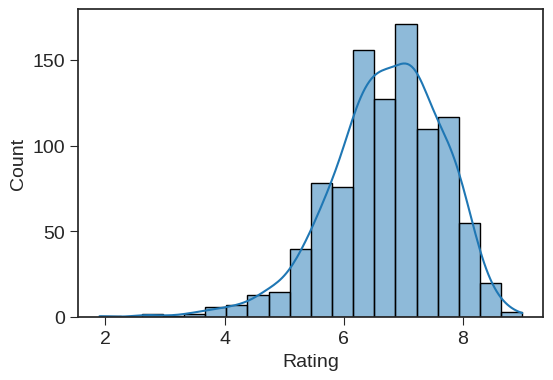

In [11]:
sns.histplot(df['Rating'], bins=20, kde=True);

Сравним рейтинги фильмов двух режиссеров. Для этого построим на одном рисунке два графика функции плотности распределения.

In [12]:
df['Director'].value_counts()[:10]

,count
Director,
Ridley Scott,8
David Yates,6
Paul W.S. Anderson,6
Michael Bay,6
M. Night Shyamalan,6
Christopher Nolan,5
Peter Berg,5
Justin Lin,5
J.J. Abrams,5


In [13]:
df.loc[df['Director'] == 'Ridley Scott', 'Rating']

,Rating
1,7.0
102,8.0
387,6.7
470,7.8
516,6.0
521,5.3
530,6.9
737,7.1


In [14]:
df.loc[df['Director'] == 'M. Night Shyamalan', 'Rating']

,Rating
2,7.3
318,6.2
512,5.0
581,4.2
773,5.6
948,4.9


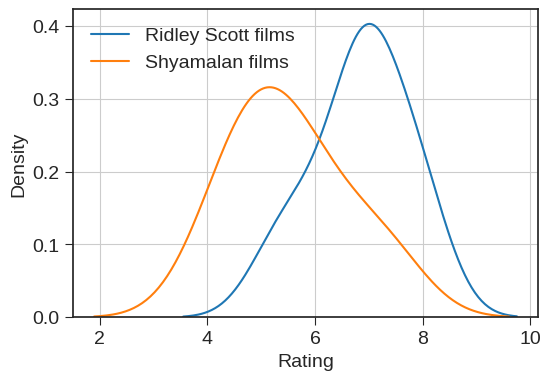

In [15]:
sns.kdeplot(df.loc[df['Director'] == 'Ridley Scott', 'Rating'],
             label='Ridley Scott films')
sns.kdeplot(df.loc[df['Director'] == 'M. Night Shyamalan', 'Rating'],
             label='Shyamalan films')
plt.legend()
plt.grid();

### Ящик с усами (boxplot)

<img src='https://drive.google.com/uc?id=1PmgGlWpWahe0cr23fTMVfm3i2MKnUcuu' width=700 align='center'></img>

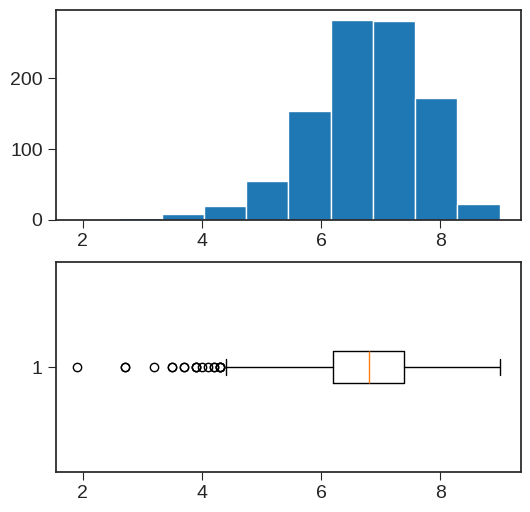

In [16]:
plt.figure(figsize=(6,6))

plt.subplot(2, 1, 1)
plt.hist(df['Rating'], edgecolor='white')

plt.subplot(2, 1, 2)
plt.boxplot(df['Rating'], vert=False);

In [17]:
df_dir = df.loc[df.Director.isin(['Ridley Scott', 'M. Night Shyamalan']), ['Director', 'Rating']]
df_dir

,Director,Rating
1,Ridley Scott,7.0
2,M. Night Shyamalan,7.3
102,Ridley Scott,8.0
318,M. Night Shyamalan,6.2
387,Ridley Scott,6.7
470,Ridley Scott,7.8
512,M. Night Shyamalan,5.0
516,Ridley Scott,6.0
521,Ridley Scott,5.3
530,Ridley Scott,6.9


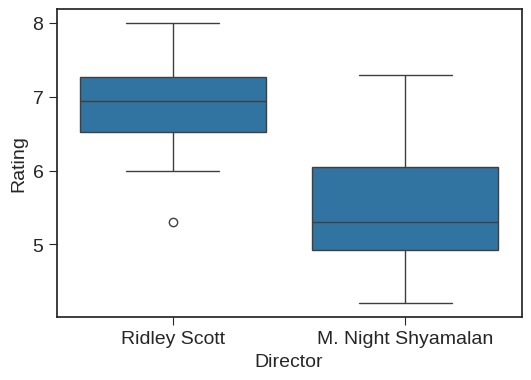

In [18]:
sns.boxplot(x=df_dir['Director'], y=df_dir['Rating']);

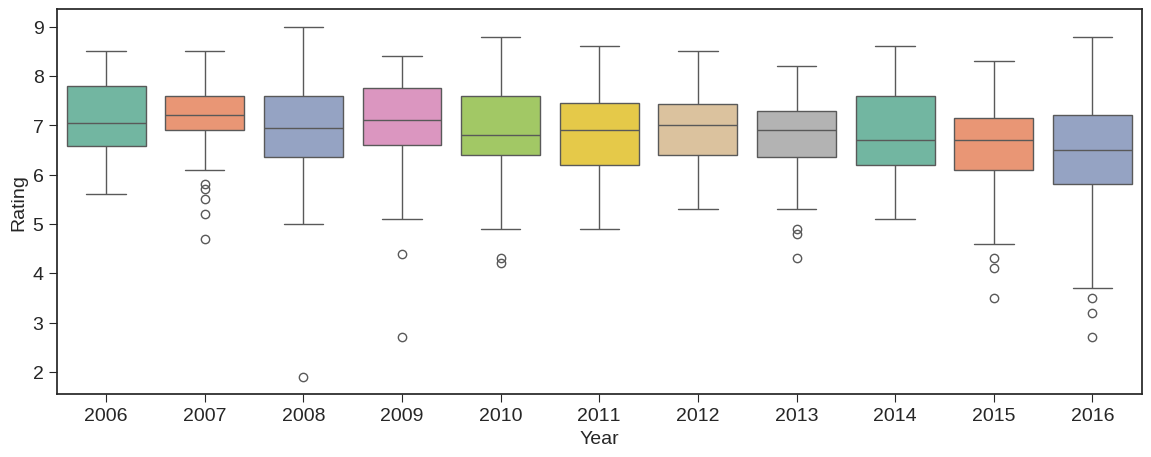

In [36]:
plt.figure(figsize=(14, 5))
sns.boxplot(x=df['Year'], y=df['Rating'], hue=df['Year'], palette='Set2', legend=False);

### Точечная диаграмма (scatter plot)

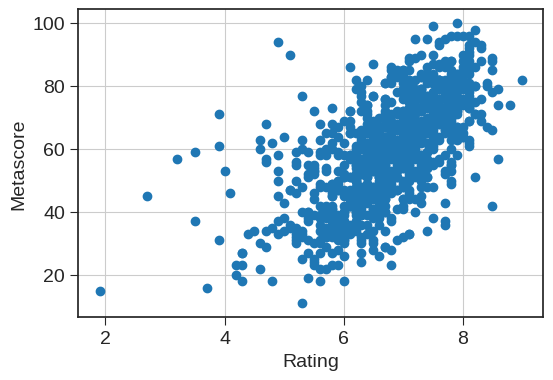

In [20]:
plt.scatter(x='Rating', y='Metascore', data=df)
plt.xlabel('Rating')
plt.ylabel('Metascore')
plt.grid();

### Столбчатая диаграмма (barplot)

Director
Ridley Scott          8
David Yates           6
Paul W.S. Anderson    6
Michael Bay           6
M. Night Shyamalan    6
Christopher Nolan     5
Peter Berg            5
Justin Lin            5
J.J. Abrams           5
Danny Boyle           5
Name: count, dtype: int64


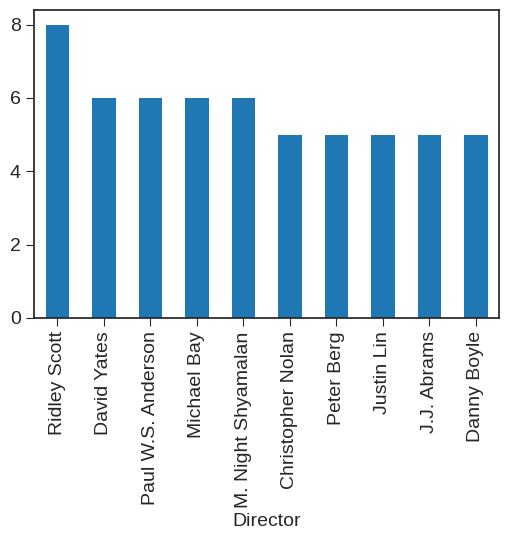

In [21]:
df_dir = df['Director'].value_counts()[:10]
print(df_dir)
df_dir.plot(kind='bar');

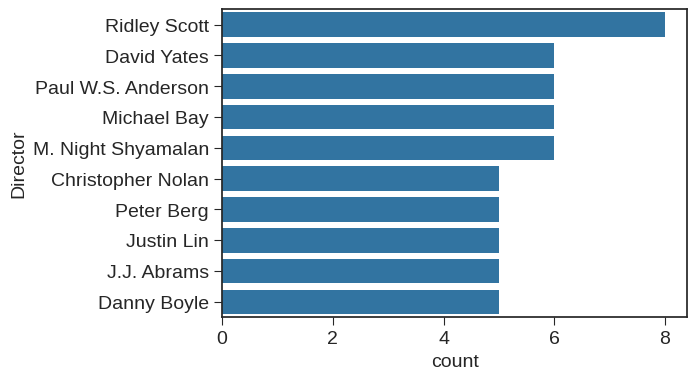

In [22]:
sns.barplot(x=df_dir, y=df_dir.index);

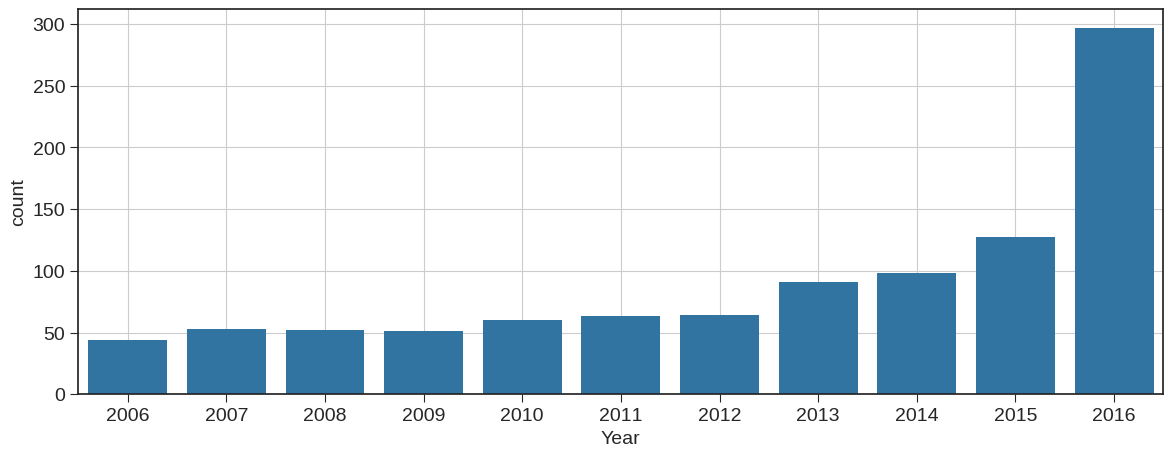

In [23]:
plt.figure(figsize=(14, 5))
sns.countplot(x='Year', data=df)
plt.grid();

In [24]:
df_dir = df.loc[df.Director.isin(['Ridley Scott', 'M. Night Shyamalan']), ['Director', 'Title', 'Year']]
df_dir

,Director,Title,Year
1,Ridley Scott,Prometheus,2012
2,M. Night Shyamalan,Split,2016
102,Ridley Scott,The Martian,2015
318,M. Night Shyamalan,The Visit,2015
387,Ridley Scott,Robin Hood,2010
470,Ridley Scott,American Gangster,2007
512,M. Night Shyamalan,The Happening,2008
516,Ridley Scott,Exodus: Gods and Kings,2014
521,Ridley Scott,The Counselor,2013
530,Ridley Scott,A Good Year,2006


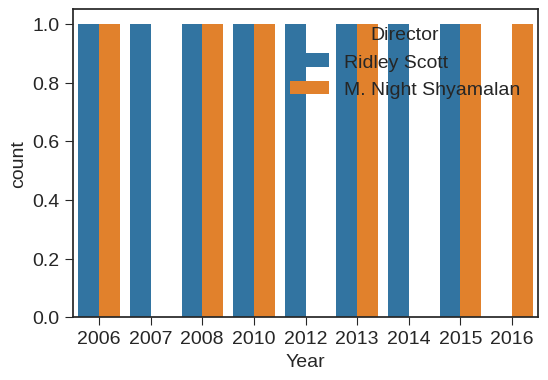

In [25]:
sns.countplot(x='Year', hue='Director', data=df_dir);

### Круговая диаграмма (pie chart)

In [26]:
df_year = pd.DataFrame(df['Year'].value_counts())
df_year

,count
Year,
2016,297
2015,127
2014,98
2013,91
2012,64
2011,63
2010,60
2007,53
2008,52


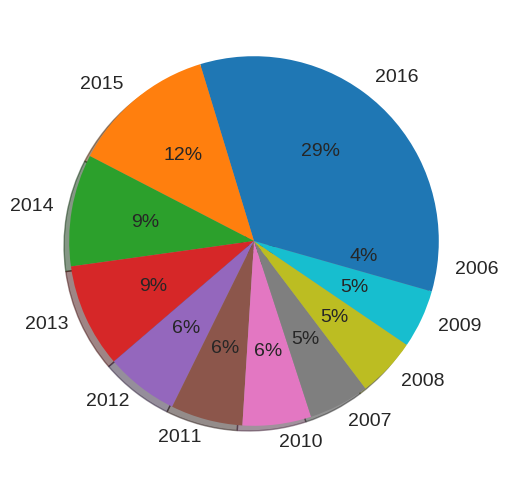

In [30]:
plt.figure(figsize=(6, 6))
plt.pie(labels=df_year.index, x=df_year['count'], autopct='%d%%', shadow=True);

### Интерактивные графики

In [38]:
import plotly.express as px
px.pie(names=df_year.index, values=df_year['count'])

In [39]:
px.histogram(df, x='Rating', nbins=20, text_auto=True)

In [40]:
px.scatter(df, x='Rating', y='Metascore', color='Revenue (Millions)')

## Задания

1. Загрузите датасет IMDB-Movie-Data.csv. Постройте гистограмму и график функции плотности распределения признака `Metascore` фильмов 2016 года. (3 балла)

In [ ]:
# код

2. Постройте точечную диаграмму для визуализации зависимости между отданными голосами за фильм (признак `Votes`) и рейтингом фильма (признак `Rating`). Сделайте вывод о зависимости рейтинга и количества голосов. (3 балла)

In [ ]:
# код

3. Постройте на одном графике гистограммы или графики функций распределения или боксплоты для рейтингов комедий и триллеров. Сравните рейтинги и сделайте вывод. (3 балла)

In [ ]:
# код

4. Постройте столбчатую диаграмму для сравнения количеств фильмов ужасов и семейных фильмов с 2010 по 2016 года. (3 балла)

In [ ]:
# код